In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw04.ipynb")

# 🚴‍♂️ Homework 4: Bike Sharing

### Due Date: Thursday, October 2, 11:59 PM
You must submit this assignment to Pensieve by the on-time deadline, Thursday, October 2, 11:59 PM. Please read the syllabus for the Slip Day policy. No late submissions beyond what is outlined in the Slip Day policy will be accepted. **We strongly encourage you to submit your work to Pensieve several hours before the stated deadline.** This way, you will have ample time to reach out to staff for support if you encounter difficulties with submission. While course staff is happy to help guide you with submitting your assignment ahead of the deadline, we will not respond to last-minute requests for assistance.

Please read the instructions carefully when submitting your work to Pensieve. 

## 👥 Collaboration Policy

Data science is a collaborative activity. While you may talk with others about the homework, we ask that you **write your solutions individually**. If you discuss the assignments with others, please **include their names** below.

**Collaborators**: *list collaborators here*

## 📜 This Assignment

Bike-sharing systems are a new(ish!) generation of traditional bike rentals where the process of signing up, renting, and returning is automated. Using these systems, users can easily rent a bike from one location and return it to another. 

In this assignment, you will clean, visualize, explore, and analyze bike-sharing data from Washington, D.C. You will also investigate open-ended questions. These open-ended questions ask you to think critically about how the plots you have created provide insight into the data.

After completing this assignment, you should be comfortable with:

* Reading plain text delimited data into `pandas`,
* Wrangling data for analysis,
* Using EDA to learn about your data, and 
* Making informative plots.

## ✅ Grading
As always, grading will be down into auto-graded answers and manually-graded (written) answers. Most of the plots will be manually graded. Your plots should be *similar* to the given examples. We will accept small variations, such as color differences or slight variations in scale. However, it is in your best interest to make the plots as similar as possible. 

**Note:** ALL plotting questions from here on out, we will expect **descriptive titles, axis labels, legends, etc**. The following question serves as a good guideline on what is "enough": *If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question*

## 💯 Score Breakdown 



Question | Manual | Points
--- |---| ---
0 |No |1
1a |Yes |2
2a |No |3
2b |No |3
3a |Yes |2
3b |Yes |2
3c |Yes |2
3d |Yes |2
4a |Yes |3
4b |Yes |1
4c |Yes |3
5a |Yes |2
5b |Yes |2
5c |Yes |2
6a |No |1
6b |Yes |3
7 |Yes |2
Total |28 |35

## 🏎️ Before You Start

For each question in the assignment, please write down your answer in the answer cell(s) right below the question. 

We understand that it is helpful to have extra cells breaking down the process towards reaching your final answer. If you happen to create new cells below your answer to run code, **NEVER** add cells between a question cell and the answer cell below it. It will cause errors when we run the autograder, and it will sometimes cause a failure to generate the PDF file.

**Important note: The local autograder tests will not be comprehensive. You can pass the automated tests in your notebook but still fail tests in the autograder.** Please be sure to check your results carefully.

Finally, unless we state otherwise, **do not use for loops or list comprehensions**. The majority of this assignment can be done using built-in commands in `pandas` and `NumPy`.  Our autograder isn't smart enough to check, but you're depriving yourself of key learning objectives if you write loops / comprehensions, and you also won't be ready for the midterm.

### Debugging Guide
If you run into any technical issues, we highly recommend checking out the [Data 100 Debugging Guide](https://ds100.org/debugging-guide/). In this guide, you can find general questions about Jupyter notebooks / Datahub, Pensieve, and common `pandas` errors.

In [2]:
# Run this cell to set up your notebook. Make sure ds100_utils.py is in this assignment's folder
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
from pathlib import Path
import ds100_utils

# Default plot configurations
%matplotlib inline
plt.rcParams['figure.figsize'] = (16,8)
plt.rcParams['figure.dpi'] = 150
sns.set()

import warnings
warnings.filterwarnings("ignore")

from IPython.display import display, Latex, Markdown

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />



## 📊 Question 0: Midterm Availability Form

#### For students **without** DSP Exam Accommodations

Before you begin this homework assignment, make sure you've read the following [**Ed post**](https://edstem.org/us/courses/83980/discussion/7012043), and that you've filled out the following [**Midterm Availability form**](https://docs.google.com/forms/d/e/1FAIpQLSc0MyhwCP3ViTLHSv8aiiKdkzFCZP5HG26ai-x2Y1RFaxFyrw/viewform). 

If you do not fill out the form by **Wednesday, October 1st, 11:59 PM**, you will be randomly assigned one of the following times to take the exam:

- **Thursday, October 16 @ 11:00 AM**
- **Thursday, October 16 @ 06:30 PM**
- **Thursday, October 16 @ 08:00 PM**

Once you have filled out the form, set `q0 = True`.


#### For students **with** DSP Exam Accommodations

Set `q0 = True` once you've read this [**Ed Post**](https://edstem.org/us/courses/83980/discussion/7018006). You should **not** fill up the midterm availability form above.

In [3]:
# Set q0 = True
q0 = True

In [4]:
grader.check("q0")

q0 results: All test cases passed!

<hr style="border: 1px solid #fdb515;" />

## 💽 Loading Bike Sharing Data
For this homework assignment we will explore data collected from a bike-sharing system in Washington, DC.

Here are variables in the data:

Variable       | Description
-------------- | ------------------------------------------------------------------
instant | unique ID
dteday | date
season | 1. spring <br> 2. summer <br> 3. fall <br> 4. winter
yr | year (0: 2011, 1:2012)
mnth | month (1 to 12)
hr | hour (0 to 23)
holiday | whether the day is a holiday or not
weekday | day of the week
workingday | if the day is neither a weekend nor a holiday
weathersit | 1. clear or partly cloudy <br> 2. mist and clouds <br> 3. light snow or rain <br> 4. heavy rain or snow
temp | normalized temperature in Celsius (divided by 41)
atemp | normalized "feels-like" temperature in Celsius (divided by 50)
hum | normalized percent humidity (divided by 100)
windspeed| normalized wind speed (divided by 67)
casual | count of casual users
registered | count of registered users
cnt | count of total rental bikes, including casual and registered  

###  📥 Download the Data

In [5]:
# Run this cell to download the data; no further action is needed.

data_url = 'https://github.com/DS-100/fa20/raw/gh-pages/resources/assets/datasets/hw3-bikeshare.zip'
file_name = 'data.zip'
data_dir = 'data/'

dest_path = ds100_utils.fetch_and_cache(data_url=data_url, data_dir=data_dir, file=file_name)
print('Saved at {}'.format(dest_path))

zipped_data = zipfile.ZipFile(dest_path, 'r')

data_dir = Path('data')
zipped_data.extractall(data_dir)


print("Extracted Files:")
for f in data_dir.glob("*"):
    print("\t",f)

Using version already downloaded: Tue Feb 24 09:50:58 2026
MD5 hash of file: 2bcd2ca89278a8230f4e9461455c0811
Saved at data\data.zip
Extracted Files:
	 data\bikeshare.txt
	 data\data.zip


### 🔎 Examining the File Contents

As a quick, ungraded exercise, try and see if you can identify the file format of the file below. (No answer required).

In [6]:
# Run this cell to look at the top of the file; no further action is needed.
for line in ds100_utils.head(data_dir/'bikeshare.txt'):
    print(line,end="")

instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0,3,13,16
2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.8,0,8,32,40
3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.8,0,5,27,32
4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0,3,10,13


### 🗻 Size
Is the file big?  How many records do we expect to find? Once again, this is ungraded, and there is no answer required.

In [7]:
# Run this cell to view some metadata; no further action is needed.
print("Size:", (data_dir/"bikeshare.txt").stat().st_size, "bytes")
print("Line Count:", ds100_utils.line_count(data_dir/"bikeshare.txt"), "lines")

Size: 1156736 bytes
Line Count: 17380 lines


### 💾 Loading the Data

The following code loads the data into the `bike` `DataFrame`.

In [8]:
# Run this cell to load the data; no further action is needed.
bike = pd.read_csv(data_dir/'bikeshare.txt')
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Below, we show the shape of the file. 

You should see that the size of the `DataFrame` matches the number of lines in the file minus the header row.

In [9]:
bike.shape

(17379, 17)

<hr style="border: 1px solid #fdb515;" />

## 📊 Question 1: Examining the Data

Before we start working with the data, let's examine its granularity.

<!-- BEGIN QUESTION -->

<br>

--- 
### 📊 Question 1a
Granularity refers to the level of detail in a dataset—what each row represents in terms of time, space, or entity. In this dataset, each row corresponds to **bike-sharing data per hour** in Washington, DC. Based on the granularity and the variables present in the data, answer the following questions in 2-3 sentences:
1. What might be some of the limitations of using this data? 
2. What is one additional data category/variable that one could collect to address some of these limitations?

_We don understand what does all the numbers mean. There should be the definations of the numbers._

<!-- END QUESTION -->



In [10]:
# Use this cell for scratch work. If you need to add more cells for scratch work, add them BELOW this cell.

<hr style="border: 1px solid #fdb515;" />

## 📈 Question 2: Data Preparation
Several variables in the dataset are numeric/integer but actually represent categorical data. These include `holiday`, `weekday`, `workingday`, and `weathersit`.

In this problem, we will convert these four variables to strings that specify the categories. Specifically, use 3-letter labels (`Sun`, `Mon`, `Tue`, `Wed`, `Thu`, `Fri`, and `Sat`) for `weekday`. For `holiday` and `workingday`, use `yes`/`no`.

We will *mutate* the `bike` `DataFrame`, which means we will overwrite the corresponding variables in `bike`. This is an in-place data transformation, so the changes will be documented in the notebook for future reference. Ensure that the underlying data file `bikeshare.txt` remains unmodified.


<br>

--- 
### 📈 Question 2a 


Decode the `holiday`, `weekday`, `workingday`, and `weathersit` fields:

1. `holiday`: Convert to `yes` and `no`.  **Hint:** There are fewer holidays.
1. `weekday`: Mutate the `'weekday'` column to use the 3-letter label (`'Sun'`, `'Mon'`, `'Tue'`, `'Wed'`, `'Thu'`, `'Fri'`, and `'Sat'`) instead of its current numerical values. Assume `0` corresponds to `Sun`, `1` to `Mon`, and so on, in order of the previous sentence.
1. `workingday`: Convert to `yes` and `no`.
1. `weathersit`: You should replace each value with one of `Clear`, `Mist`, `Light`, or `Heavy`. Assume `1` corresponds to `Clear`, `2` corresponds to `Mist`, and so on in order of the previous sentence.

**Note:** If you mutate any of the fields above, then they will not be in the format of their original `.txt` file. As a debugging tip, if you want to revert changes, rerun the cell above that loads in the `bike` `DataFrame`.

**Hint:** One approach is to use the `replace`[(documentation)](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.replace.html) method of the `pd.DataFrame` class.

In [11]:
# Modify holiday, weekday, workingday, and weathersit here.
bike['holiday']=bike['holiday'].map({0:'no',1:'yes'})
bike['weekday']=bike['weekday'].map({0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'})
bike['workingday']=bike['workingday'].map({0:'no',1:'yes'})
bike['weathersit']=bike['weathersit'].map({1:'Clear',2:'Mist',3:'Light',4:'Heavy'})
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1


In [12]:
grader.check("q2a")

q2a results: All test cases passed!

<br>

--- 
### 📈 Question 2b
In the next few questions, we will analyze the daily number of registered and unregistered users.

Construct a `DataFrame` named `daily_counts` indexed by `dteday` with the following columns:
* `casual`: Total number of casual riders for each day.
* `registered`: Total number of registered riders for each day.
* `workingday`: Whether that day is a working day or not (`yes` or `no`).

**Hint:** This question is similar to Question 2b in Homework 2B.

In [13]:
daily_counts = bike.groupby('dteday').agg(casual=('casual','sum'),registered=('registered','sum'),workingday=('workingday','first'))
daily_counts.head()

,casual,registered,workingday
dteday,,,
2011-01-01,331,654,no
2011-01-02,131,670,no
2011-01-03,120,1229,yes
2011-01-04,108,1454,yes
2011-01-05,82,1518,yes


In [14]:
grader.check("q2b")

q2b results: All test cases passed!

<hr style="border: 1px solid #fdb515;" />

## 🚲 Question 3: Exploring the Distribution of Riders

Let's begin by comparing the distribution of the daily counts of casual and registered riders. Questions 3-6 require using many visualization methods, so for your convenience, we have summarized a few useful ones below.

### Matplotlib and Seaborn Table of Common Functions

`x` and `y` are sequences of values (i.e., arrays, lists, or `Series`).

| Function | Description |
| -------- | ----------- |
| `plt.title(name)` | Adds a title `name` to the current plot. |
| `plt.xlabel(name)` | Adds a label `name` to the x-axis. |
| `plt.ylabel(name)` | Adds a label `name` to the y-axis. |
| `plt.plot(x, y)` | Creates a line plot of `x` against `y`. |
| `plt.scatter(x, y)` | Creates a scatter plot of `x` against `y`. |
| `plt.hist(x, bins=None)` | Creates a histogram of `x`; `bins` can be an integer or a sequence. |
| `plt.bar(x, height)` | Creates a bar plot of categories `x` and corresponding heights `height`. |
| `sns.histplot(data=, x=, y=, hue=, kde=)` | Creates a distribution plot; `data` is a `DataFrame`; `x`, `y` are column names in `data` that specify positions on the `x` and `y` axes; `hue` is a column name in `data` that adds subcategories to the plot based on `hue`; `kde` is a boolean that determines whether to overlay a KDE curve. |
| `sns.lineplot(data=, x=, y=, hue=)` | Creates a line plot. |
| `sns.scatterplot(data=, x=, y=, hue=, size=)` | Creates a scatter plot; `size` is a vector that contains the size of the point for each subcategory based on `hue`. |
| `sns.kdeplot(data=, x=, y=)` | Creates a kernel density estimate plot; `data` is a `DataFrame`; `x`, `y` are column names in `data` that specify positions on the `x` and `y` axes. |
| `sns.jointplot(data=, x=, y=, kind=)` | Creates a joint plot of 2 variables with a KDE plot in the middle and a distribution plot for each variable on the sides; `kind` determines the visualization type for the distribution plot, can be `scatter`, `kde` or `hist`. |

**Note**: This list of functions and parameters is **not** exhaustive. You may need to reference and explore more documentation to answer the following questions, but we will help you through that process.

<!-- BEGIN QUESTION -->

<br>

--- 
### 🚲 Question 3a

Use the `sns.histplot`[(documentation)](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot) function to create a plot that overlays the distribution of the daily counts of bike users.

- Use blue to represent `casual` riders, and red to represent `registered` riders. 

The temporal granularity of the records should be daily counts, which you should have after completing question 2b. In other words, you should be using `daily_counts` to answer this question.

**Hints:** 
- You will need to set the `stat` parameter appropriately to match the desired plot.
- The `label` parameter of `sns.histplot` allows you to specify, as a string, how the plot should be labeled in the legend. Although label is not explicitly documented in Seaborn, it works because `sns.histplot` internally relies on  `matplotlib`, which supports the label parameter. For example, passing in `label="My data"` would give your plot the label `"My data"` in the legend.
- You will need to make two calls to `sns.histplot`.
 

Include a `legend`, `xlabel`, `ylabel`, and `title`. Read the [seaborn plotting tutorial](https://seaborn.pydata.org/tutorial/distributions.html) if you're not sure how to add these. After creating the plot, look at it and make sure you understand what the plot is actually telling us, e.g., on a given day, the most likely number of registered riders we expect is ~4000, but it could be anywhere from nearly 0 to 7000.

<img src='images/casual_v_registered.png' width="700px" />

For all visualizations in Data 100, our grading team will evaluate your plot based on its similarity to the provided example. While your plot does not need to be _identical_ to the example shown, we do expect it to capture its main features, such as the **general shape of the distribution**, the **axis labels**, the **legend**, and the **title**. It is okay if your plot contains small stylistic differences, such as differences in color, line weight, font, or size/scale.

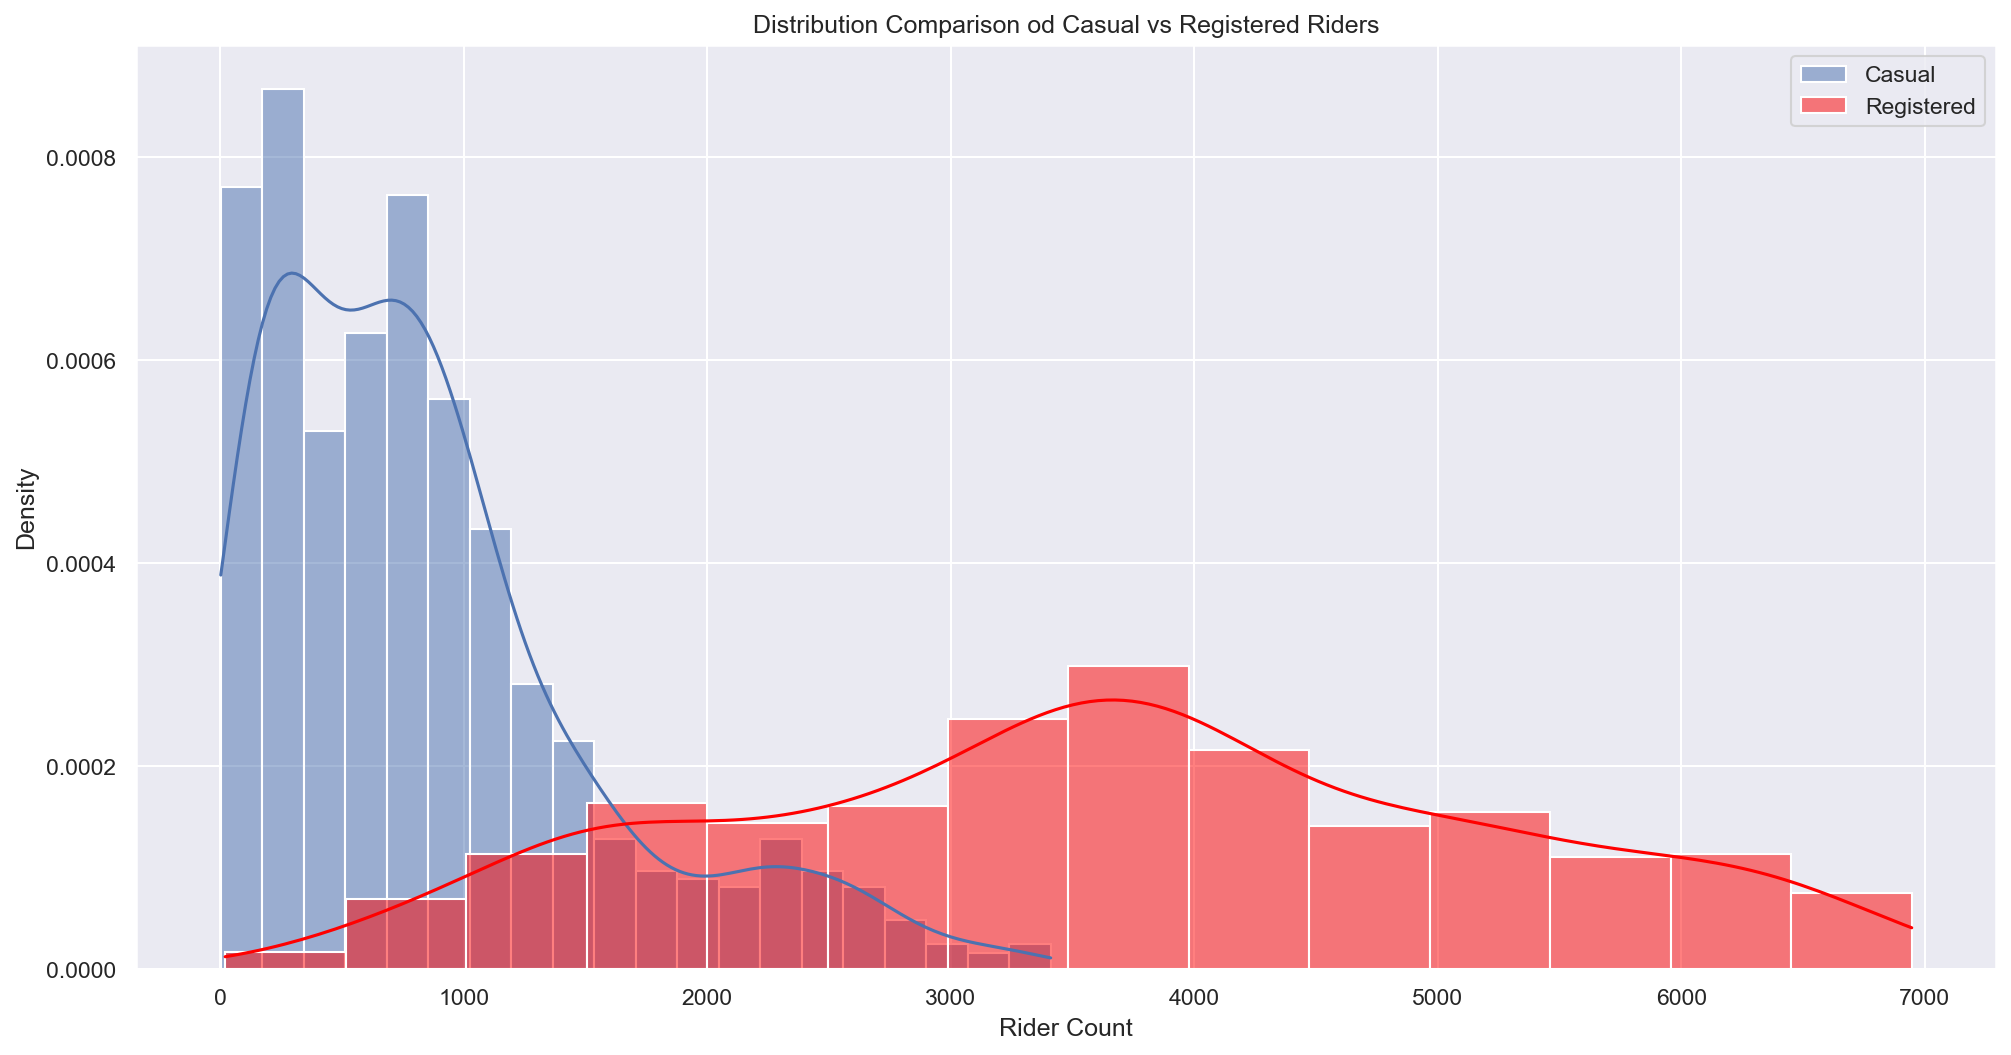

In [15]:
sns.histplot(data=daily_counts,x='casual',stat='density',kde=True,label='Casual')
sns.histplot(data=daily_counts,x='registered',color='red',alpha=0.5,stat='density',kde=True,label='Registered')
plt.xlabel('Rider Count')
plt.title('Distribution Comparison od Casual vs Registered Riders')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 
### 🚲 Question 3b

In the cell below, describe the differences you notice between the density curves for casual and registered riders.  

- Consider concepts such as modes, spread, symmetry, skewness, tails, gaps, and outliers. 
- Write your answer in 2-4 sentences.

_The mode of casual riders is much lower than the mode of registered riders. The spread of casual riders is apparently smaller than the spread of that of registered ones._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 
### 🚲 Question 3c

The density plots do not show us how the counts for `registered` and `casual` riders vary together. 

Use `sns.lmplot` [(documentation)](https://seaborn.pydata.org/generated/seaborn.lmplot.html) to create a scatter plot to investigate the relationship between casual and registered counts. 

- Use the `bike` `DataFrame` to plot hourly counts instead of daily counts.
- Color the points in the scatter plot according to whether or not the day is a working day. Your colors do not have to match ours exactly, but they should be different based on whether the day is a working day. 

<img src='images/casual_registered_working_nonworking.png' width="800px"  />

**Hints:** 
* Check out this helpful [tutorial on `lmplot`](https://seaborn.pydata.org/tutorial/regression.html).
* There are many points in the scatter plot, so make them small to help reduce overplotting. Check out the `scatter_kws` parameter of `lmplot` or check out [this tutorial](https://www.geeksforgeeks.org/data-visualization/changing-marker-size-in-seaborns-lmplot/#methods-to-change-marker-size-inlmplot).
* You can set the `height` parameter if you want to adjust the size of the `lmplot`.
* Add a descriptive title and axis labels for your plot.
* It is okay if the scales of your `x` and `y` axis (i.e., the numbers labeled on the two axes) are different from those used in the provided example.


In [16]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1


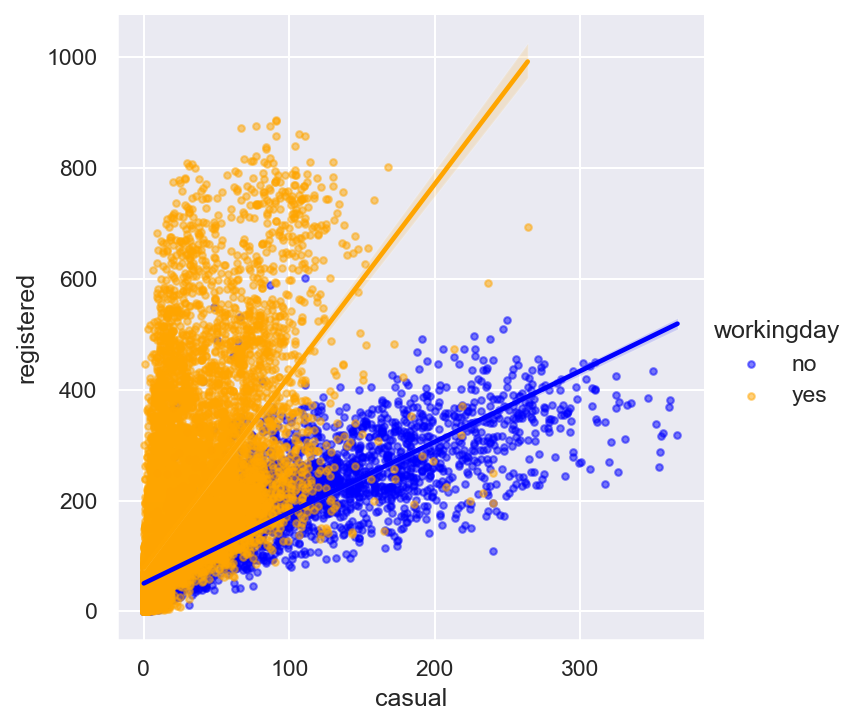

In [17]:
sns.set(font_scale=1) # This line automatically makes the font size a bit bigger on the plot. You do not need to change this line
sns.lmplot(data=bike,x='casual',y='registered',hue="workingday",palette={"yes": "orange", "no": "blue"},scatter_kws={"alpha": 0.5,'s':10} )

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 
### 🚲 Question 3d

What does this scatter plot seem to reveal about the relationship (if any) between casual and registered riders and whether or not the day is on the weekend? 

What effect does overplotting have on your ability to describe this relationship?

Write you answer in 2-3 sentences in the cell below.

_In workingdays, registered riders take the lead. In non-workingdays, casual riders outweigh registered riders.Overplotting makes it difficult to clearly see the true distribution of points._

<!-- END QUESTION -->

<hr style="border: 1px solid #fdb515;" />

## 🧑‍🎨 Question 4: Visualization
 
To address overplotting, let's try visualizing the data with another technique: bivariate kernel density estimate. You will want to read up on the documentation for `sns.kdeplot`, which can be found [here](https://seaborn.pydata.org/generated/seaborn.kdeplot.html). 

The result we wish to achieve should be a plot that looks like this:

<img src='images/bivariate_kde_of_daily_rider_types_simple.png' width="600px" />

A basic KDE plot of all the data is quite easy to generate (see below). However, this plot combines both working days and non-working days, which isn't what we want (see the example figure above).

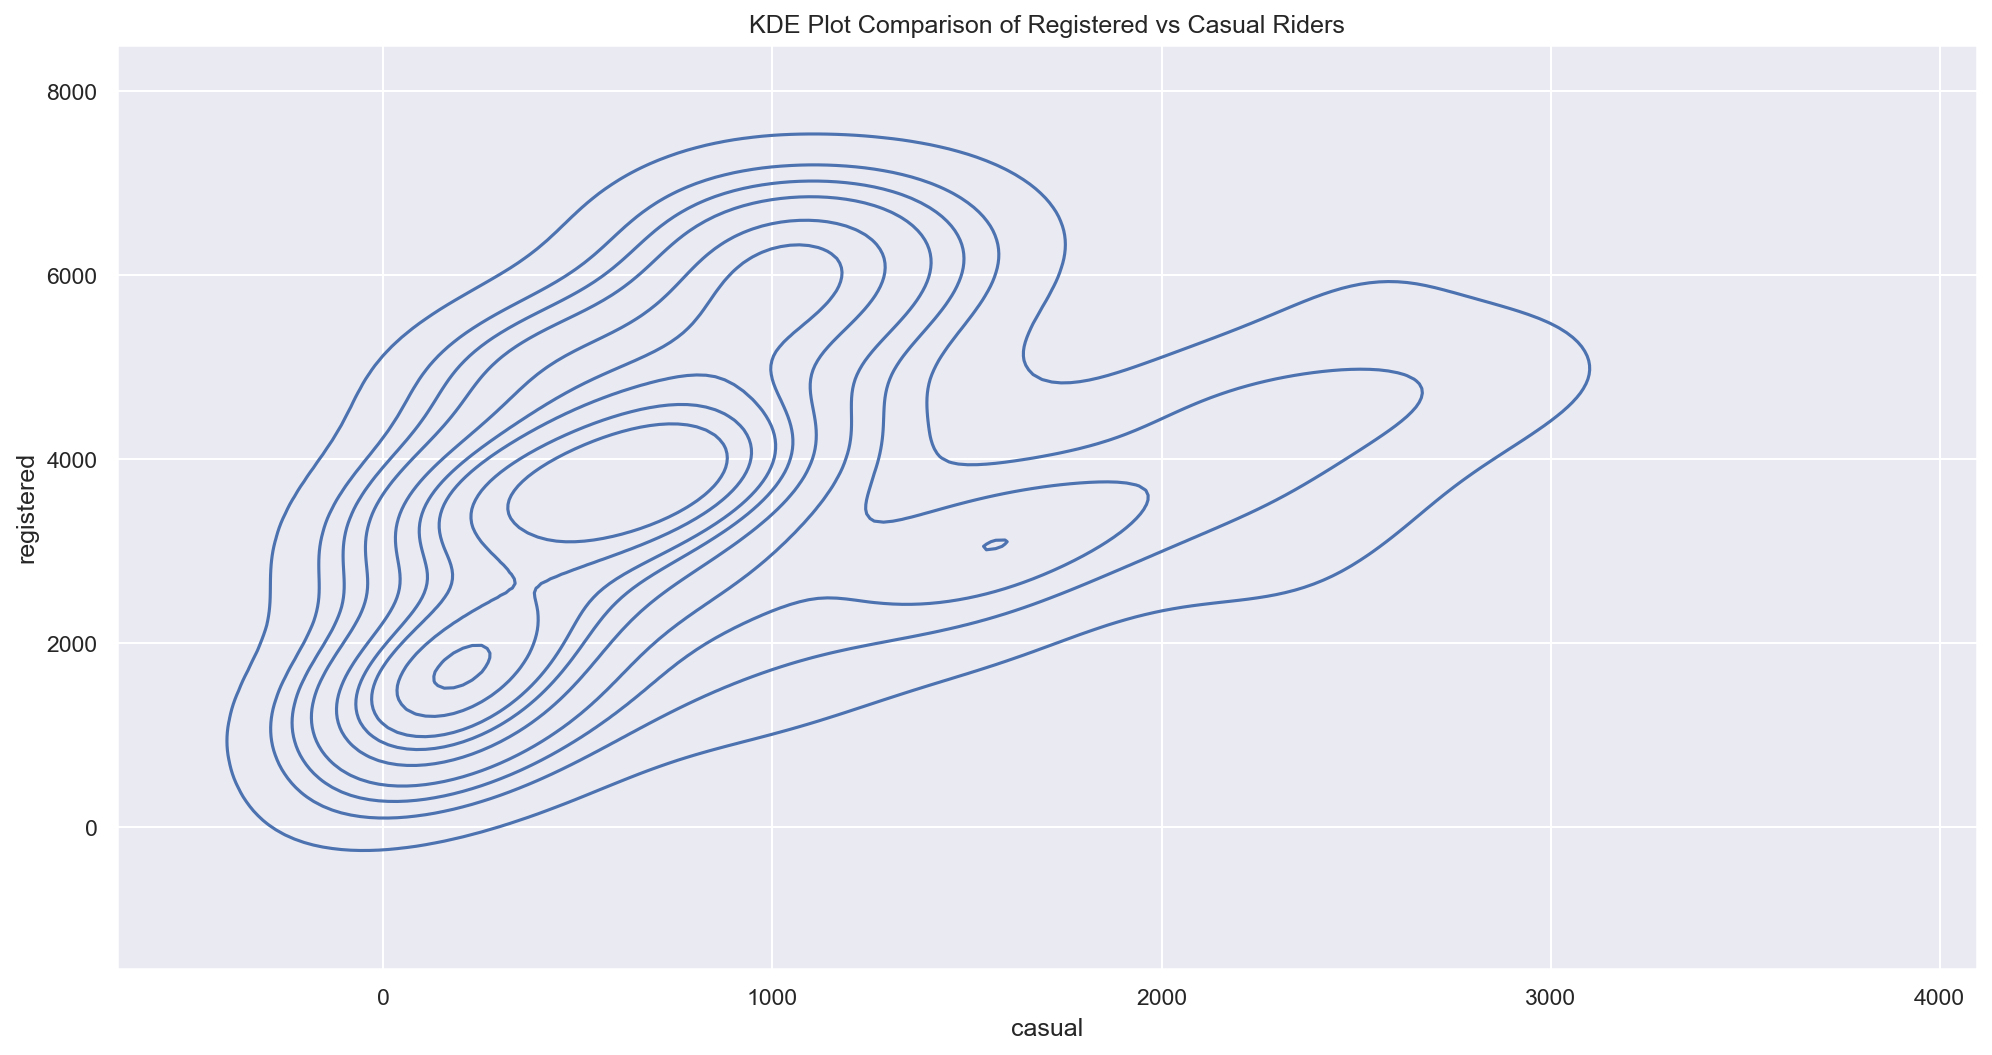

In [18]:
sns.kdeplot(data=daily_counts, x='casual', y='registered')
plt.title('KDE Plot Comparison of Registered vs Casual Riders');

<!-- BEGIN QUESTION -->

<br>

--- 

### 🧑‍🎨 Question 4a

Generate a bivariate kernel density plot with workday and non-workday separated using the `daily_counts` `DataFrame`. It should look like the first plot displayed above.

**Hint:** You only need to call `sns.kdeplot` once. Take a look at the `hue` parameter and adjust other inputs as needed.

After you get your plot working, experiment by setting `fill=True` in `kdeplot` to see the difference between the shaded and unshaded versions.

- But, **please submit your work with `fill=False`.**

<Axes: xlabel='casual', ylabel='registered'>

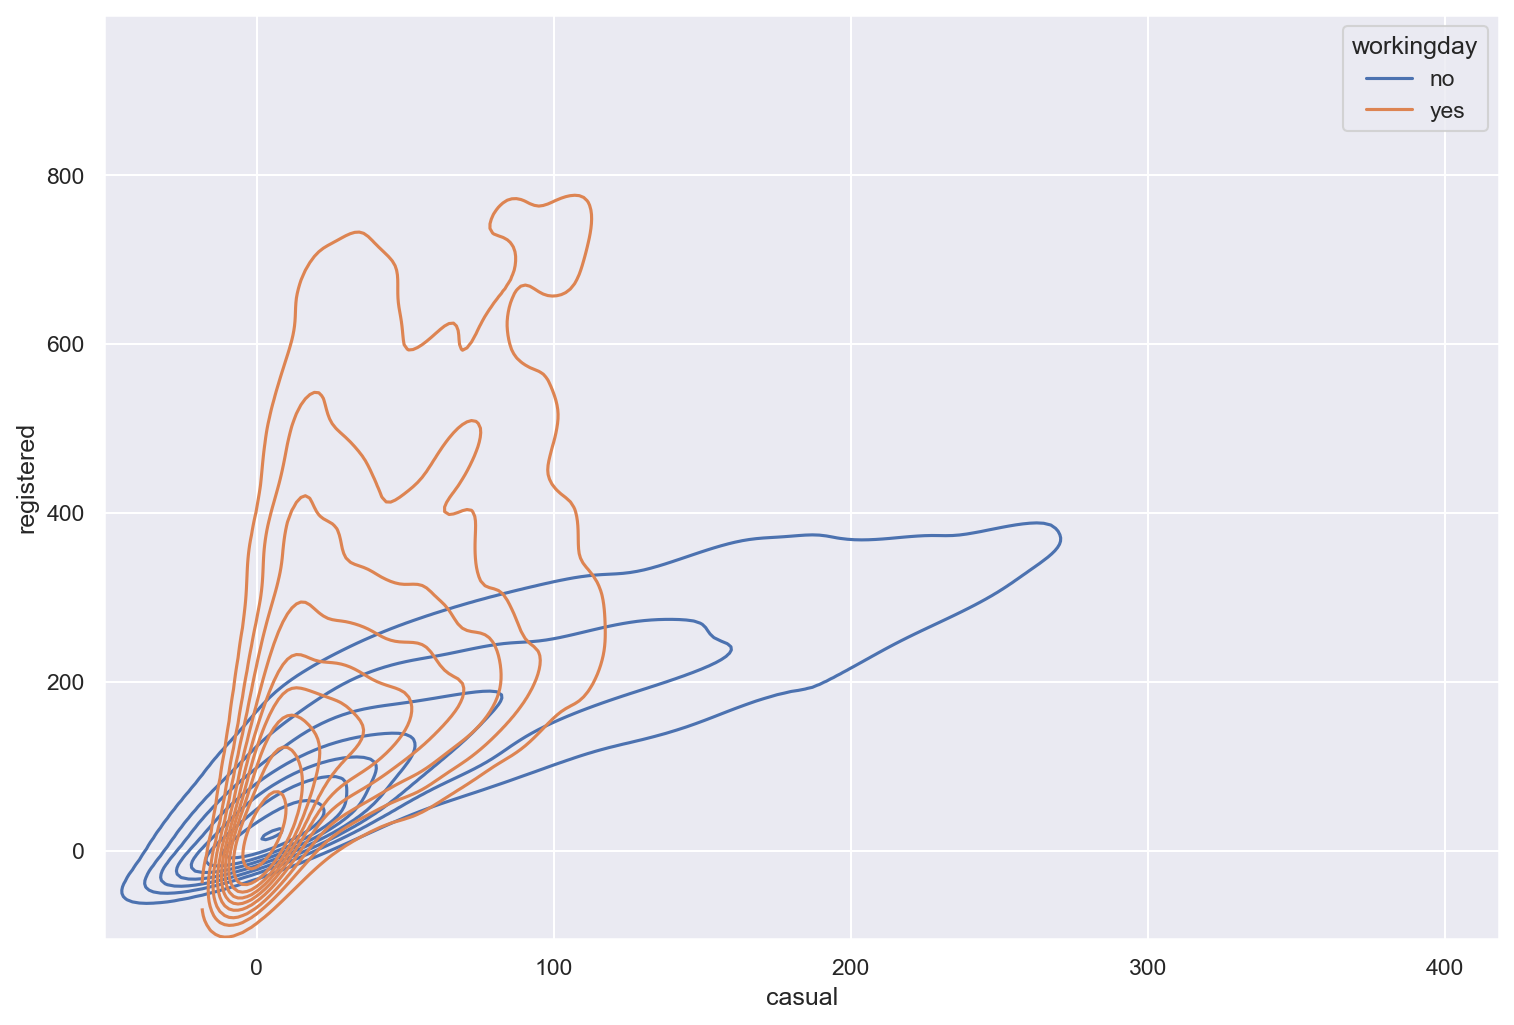

In [19]:
# Set the figure size for the plot
plt.figure(figsize=(12,8))
sns.kdeplot(data=bike,x='casual',y='registered',hue='workingday',palatte={'yes':'red','no':'blue'})

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 
### 🧑‍🎨 Question 4b
<img src='images/bivariate_kde_of_daily_rider_types_gradient.png' width="800px" />

With some modification to your Question 4a code (this modification is not in scope), we can generate the plot above. 

In 2-3 sentences, describe what the lines and the color shades of the lines signify about the data. What does each line and color represent? 

**Hint**: You may find it helpful to compare it to a contour or topographical map as shown [here](https://gisgeography.com/contour-lines-topographic-map/).

_Colour:workday/non-workday Line:indicated the density._

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 
### 🧑‍🎨 Question 4c

What additional details about the riders can you identify from this contour plot that were difficult to determine from the scatter plot?

Write your answer in 2-3 sentences in the cell below.

_Type your answer here, replacing this text._

<!-- END QUESTION -->

<hr style="border: 1px solid #fdb515;" />

## 🪶 Question 5: Understanding Daily and Monthly Patterns


---

Now, we are going to do some analysis on Daily Patterns. To do this we will create a new column `time_category` that maps the value in the `hour` variable to the following broader categories:

- **Midnight**: 2 AM to before 5 AM  
- **Morning**: 5 AM to before 11 AM  
- **Lunch Time**: 11 AM to before 2 PM  
- **Afternoon**: 2 PM to before 5 PM  
- **Evening**: 5 PM to before 9 PM  
- **Night**: 9 PM to before 2 AM  

We have done this for you in the cell below, just run the following cell.

In [20]:
# Run this cell, do not modify
def hour_to_category(hour):
    if 2 <= hour < 5:
        return "Midnight"
    elif 5 <= hour < 11:
        return "Morning"
    elif 11 <= hour < 14:
        return "Lunch Time"
    elif 14 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

bike["time_category"] = bike["hr"].apply(hour_to_category)

bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_category
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16,Night
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40,Night
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32,Midnight
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13,Midnight
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1,Midnight


<!-- BEGIN QUESTION -->

<br>

--- 
### 🪶 Question 5a

Let’s examine the behavior of riders by plotting the **average number of riders** for each **time category** (using the `time_category` column), separated by **rider type**.

Your plot should look like the plot below. It's fine if your plot's colors don't match ours exactly.

**Hint:**  
To label the x-axis correctly, use `plt.xticks()` to manually set tick positions and labels. You may need to rotate the labels for readability. Refer to the [documentation](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.xticks.html) for more details.

<img src='images/time_category_bikes.png' width="700px" />                                                                   

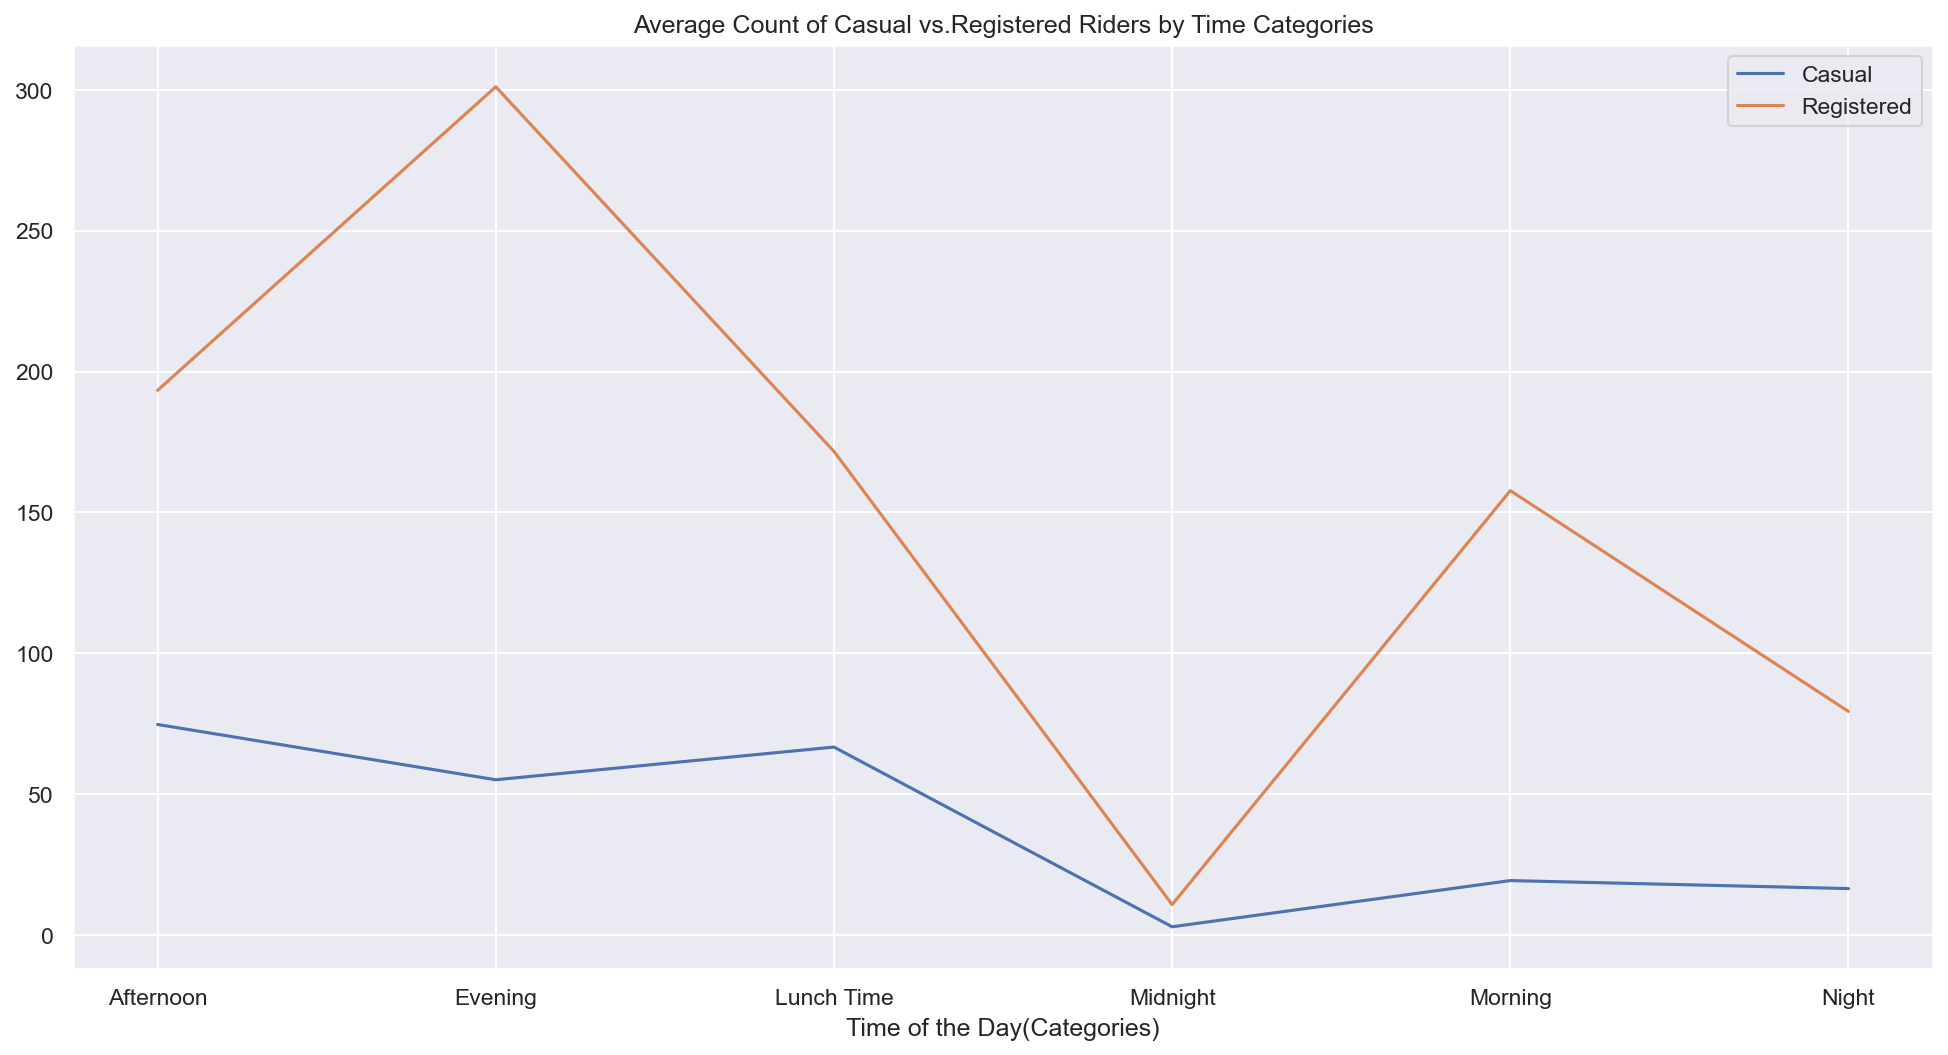

In [24]:
avg = bike.groupby('time_category')[['casual','registered']].mean()


plt.plot(avg.index, avg['casual'], label='Casual')
plt.plot(avg.index, avg['registered'], label='Registered')
plt.xlabel('Time of the Day(Categories)')
plt.title('Average Count of Casual vs.Registered Riders by Time Categories')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

<br>

--- 
### 🪶 Question 5b

Next, analyze how the average count of casual and registered riders varies by month (`mnth`). 

Compute the average number of casual and registered riders for each month in the dataset and create a line plot showing the trends.

Your plot should look like the plot below. It's fine if your plot's colors don't match ours exactly.

**Hint**: Your code will be very similar to 5a


<img src='images/monthly_avg_riders.png' width="700px" />


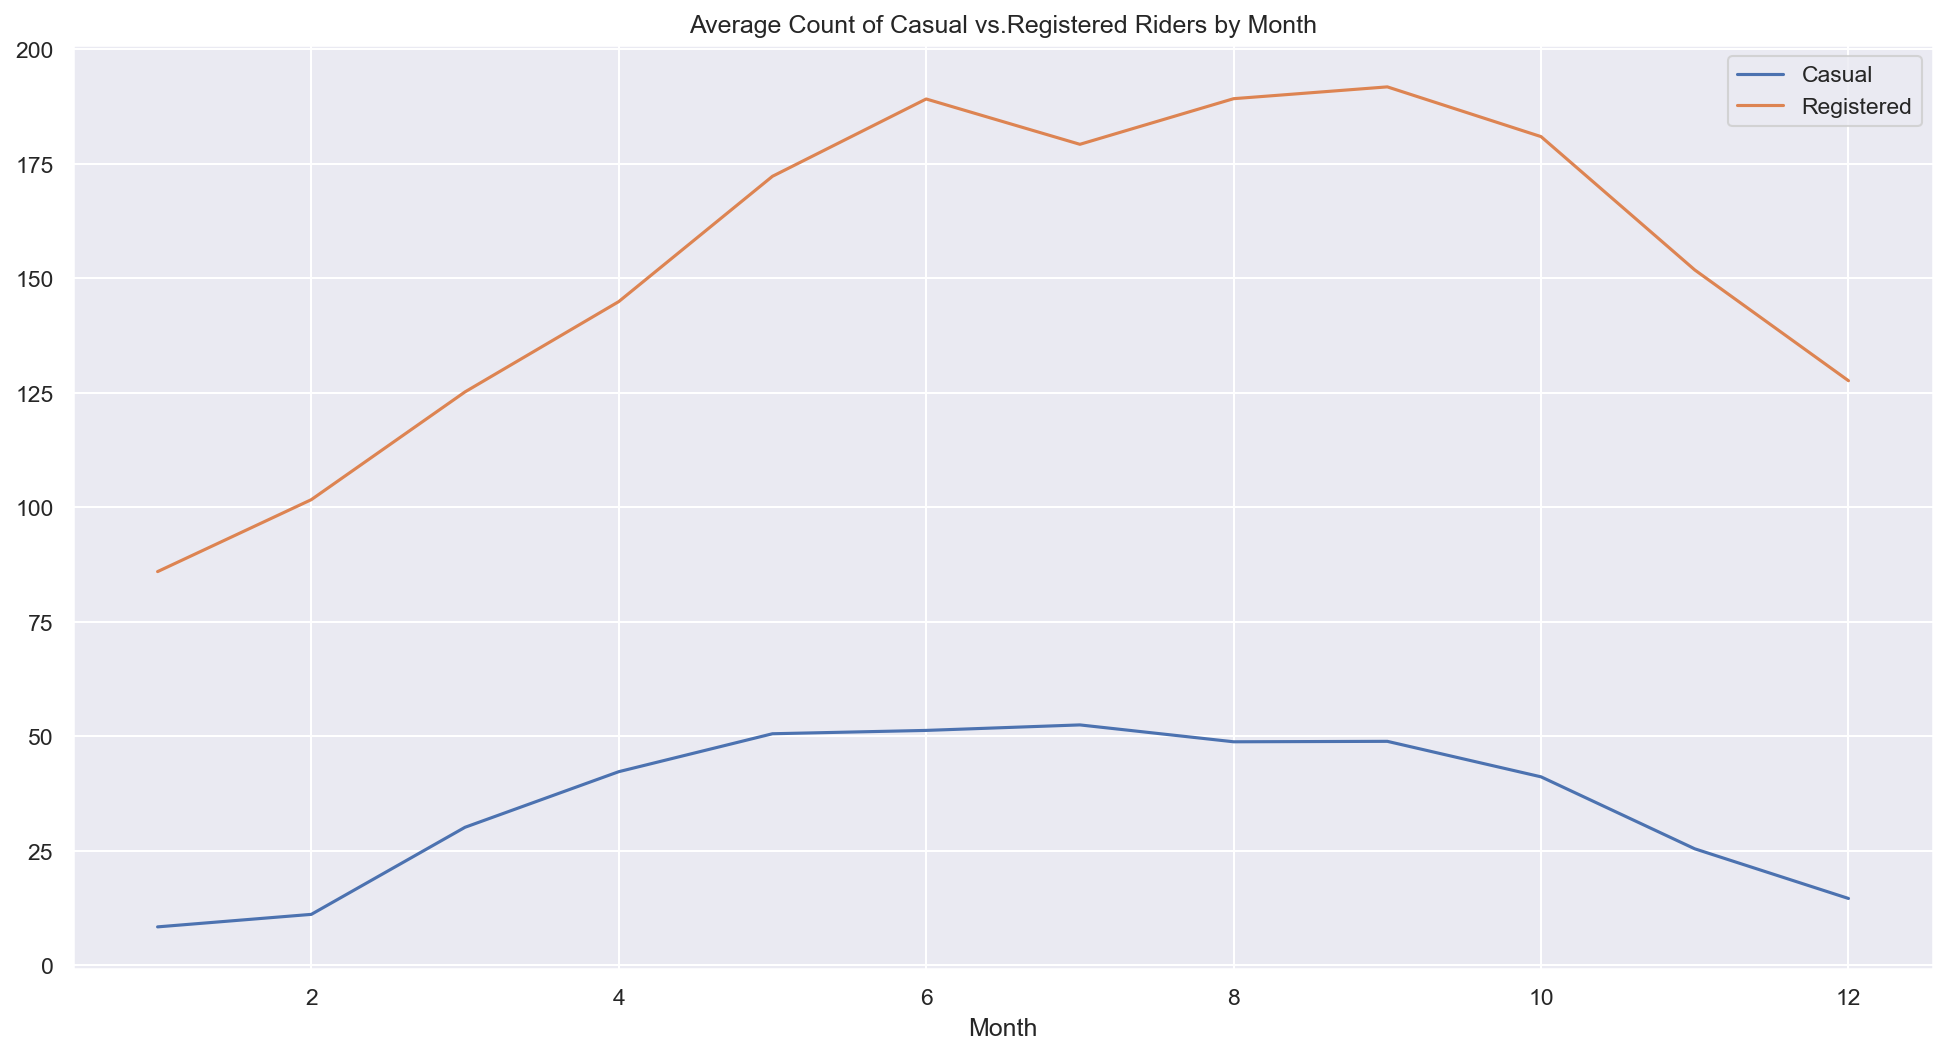

In [26]:
avg = bike.groupby('mnth')[['casual','registered']].mean()


plt.plot(avg.index, avg['casual'], label='Casual')
plt.plot(avg.index, avg['registered'], label='Registered')
plt.xlabel('Month')
plt.title('Average Count of Casual vs.Registered Riders by Month')
plt.legend()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

--- 

### 🪶 Question 5c
What can you observe from the plots generated in **5a** and **5b**?

Discuss your observations for both types of riders, and hypothesize about the meaning of the peaks and troughs of both riders' distributions.

Write your answer in 4-5 sentences in the cell below.

_Rush hours like morning and afternoon witness more usage of shared bikes due to commute demand. Summer is the peak of the year, probably because of adequate weather conditions and holidays._

<!-- END QUESTION -->

<hr style="border: 1px solid #fdb515;" />

## 🌡️ Question 6: Exploring Ride-Sharing and Weather
Now let's examine how the weather may be associated with ridership trends. First, let's look at how the proportion of casual riders changes as the weather changes.

<br>

--- 

### 🌡️ Question 6a
Create a new column `prop_casual` in the `bike` `DataFrame`, representing the proportion of casual riders out of all riders for each record.

In [27]:
bike['prop_casual']=bike['casual']/bike['cnt']

In [28]:
grader.check("q6a")

q6a results: All test cases passed!


In order to examine the relationship between the proportion of casual riders and temperature, we can create a scatter plot using `sns.scatterplot` [(documentation)](https://seaborn.pydata.org/generated/seaborn.scatterplot.html). We can even use color/hue to encode the information about the day of the week. 

Run the cell below, and you'll see we end up with a big mess that is impossible to interpret.

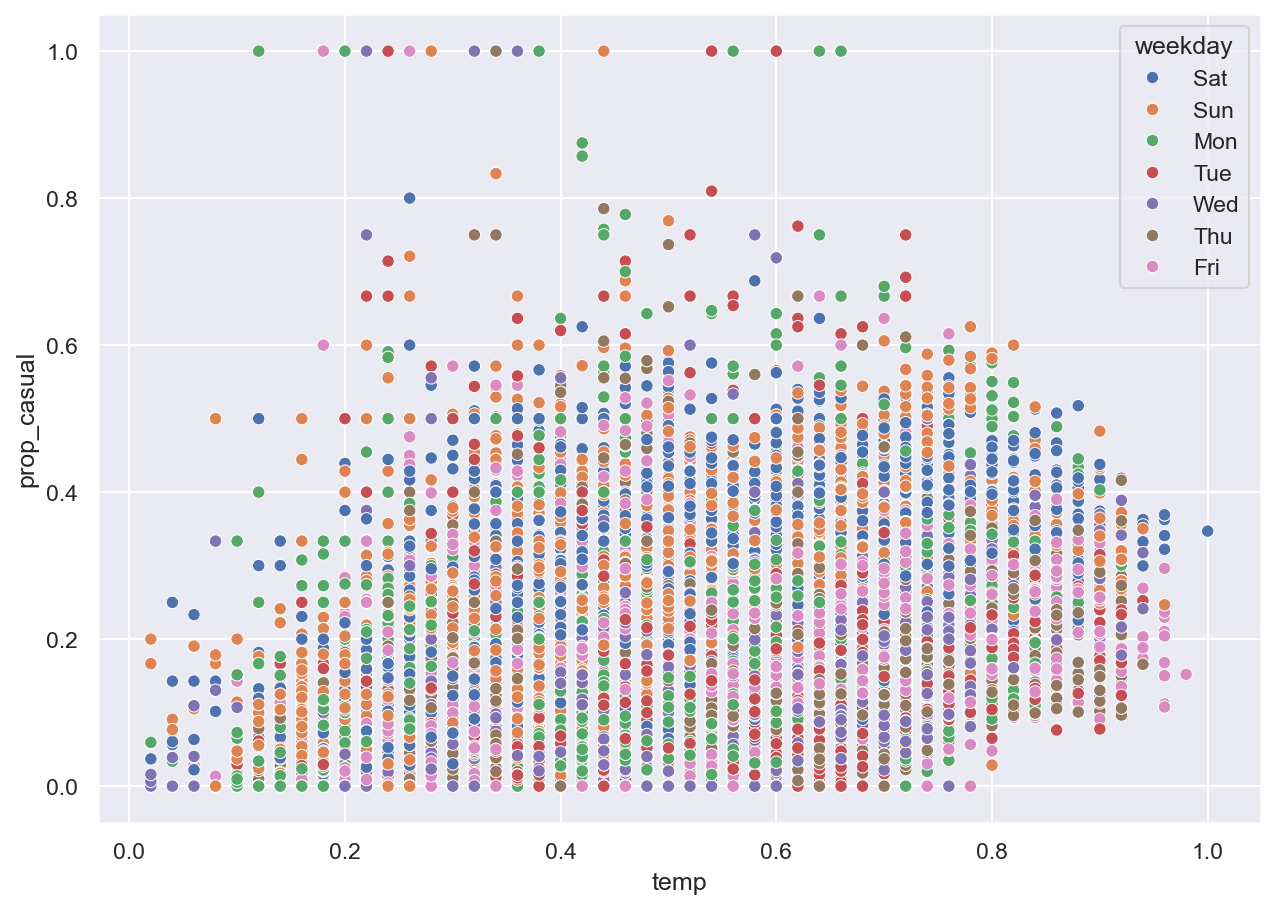

In [29]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=bike, x='temp', y='prop_casual', hue='weekday');

We could attempt linear regression using `sns.lmplot` [(documentation)](https://seaborn.pydata.org/generated/seaborn.lmplot.html) as shown below, which hints at some relationships between temperature and proportional casual, but the plot is still fairly unconvincing. 

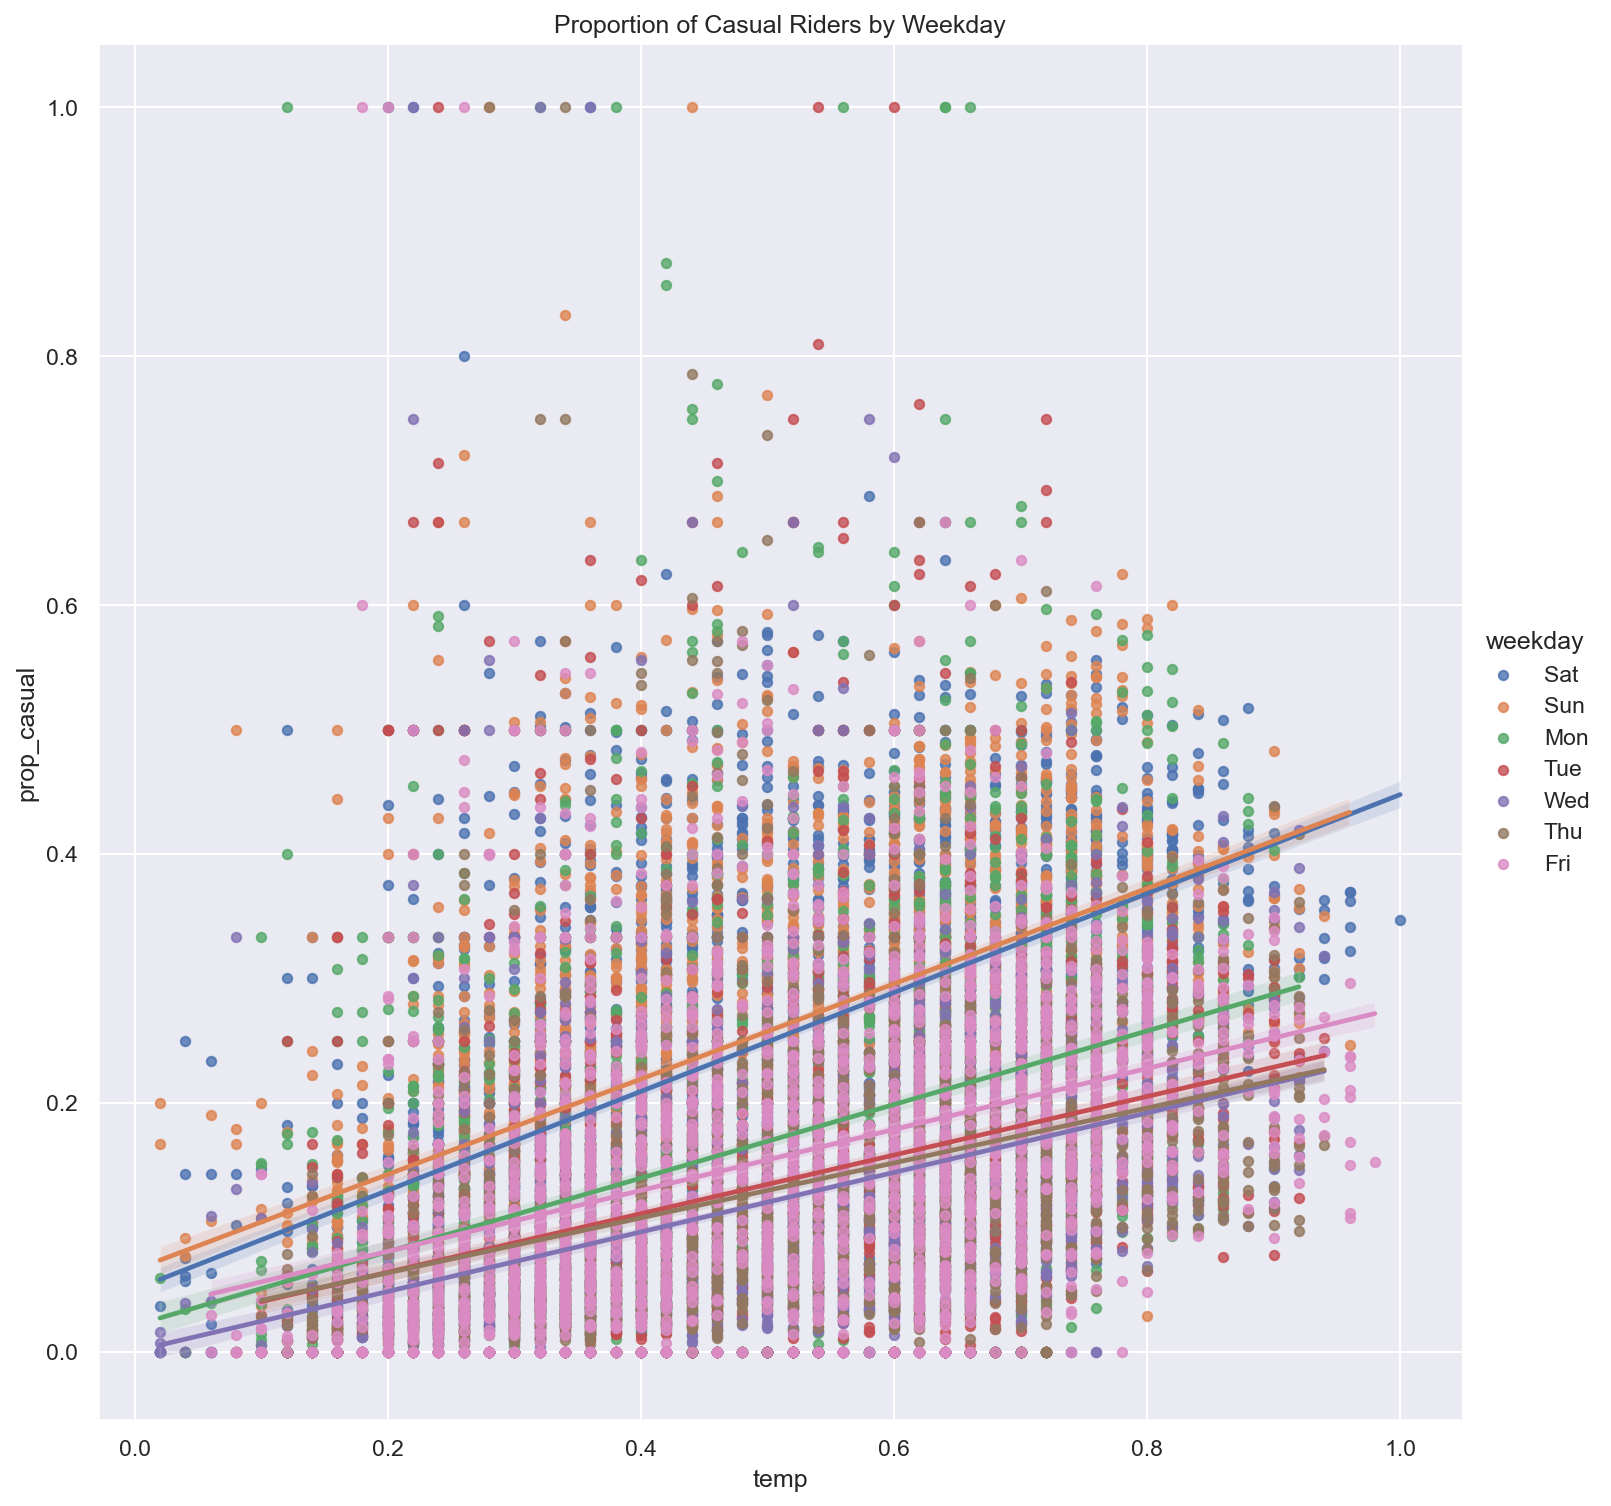

In [30]:
sns.lmplot(data=bike, x='temp', y='prop_casual', hue='weekday', scatter_kws={"s": 20}, height=10)
plt.title("Proportion of Casual Riders by Weekday");

A better approach to visualize the relationship between temperature and the proportion of casual riders is to use local smoothing techniques.

- The basic idea is to compute a representative `y` value for each `x` value that captures the data close to that `x` value.

- One such technique is [**"Locally Weighted Scatter plot Smoothing" (LOWESS/LOESS)**](https://en.wikipedia.org/wiki/Local_regression). 

- This essentially fits a curve to data rather than a line

Run the next cell to see the smoothed curves between temperature and the proportion of casual riders, one for each day of the week. 

In [32]:
from statsmodels.nonparametric.smoothers_lowess import lowess
plt.figure(figsize=(10,8))

for day in bike['weekday'].unique():
    this_day = bike[bike['weekday'] == day].copy()
    this_day['temp'] = this_day['temp'] * 41 * 9 / 5 + 32 
    ysmooth = lowess(this_day['prop_casual'], this_day['temp'], return_sorted=False)
    sns.lineplot(x=this_day['temp'], y=ysmooth, label=day)

plt.title("Temperature vs Casual Rider Proportion by Weekday")
plt.xlabel("Temperature (Fahrenheit)")
plt.ylabel("Casual Rider Proportion")
plt.legend();

ModuleNotFoundError: No module named 'statsmodels'

<!-- BEGIN QUESTION -->

<br>

--- 
### 🌡️ Question 6b
Examine the plots and answer the following questions:
1. How does casual ridership change with temperature?
2. Do the **plots alone** provide evidence of a **causal** relationship between temperature and casual ridership? Explain your reasoning. 
3. Based on **your own intuition**, do you think there is an underlying causal relationship? Justify your answer.
4. What information do the smoothed curves provide that the linear regression does not?


Write your answer in 4-5 sentences in the cell below.

_Higher the temprature is, more casual ridership there is. It cannot directly prove that there's a relationship between temp and casual ridership, because high temperature usualy come with holidays, which contribute to casual ridership largely. But based on my own intuition, I think there's and underlying causal relationship._

In [33]:
bike.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,time_category,prop_casual
0,1,2011-01-01,1,0,1,0,no,Sat,no,Clear,0.24,0.2879,0.81,0.0,3,13,16,Night,0.187500
1,2,2011-01-01,1,0,1,1,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,8,32,40,Night,0.200000
2,3,2011-01-01,1,0,1,2,no,Sat,no,Clear,0.22,0.2727,0.80,0.0,5,27,32,Midnight,0.156250
3,4,2011-01-01,1,0,1,3,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,3,10,13,Midnight,0.230769
4,5,2011-01-01,1,0,1,4,no,Sat,no,Clear,0.24,0.2879,0.75,0.0,0,1,1,Midnight,0.000000


<!-- END QUESTION -->

<br/>

---

# 🤖 Question 7: Open-Ended Question

Welcome to another **open-ended question**.


> If you have any feedback on this open-ended question, or any other homework question in Data 100, we encourage you to share your thoughts using the [content feedback form](https://docs.google.com/forms/d/e/1FAIpQLScGQhiTz1qn5gsyYUu1Be5Yz0Z_kplIRR_os8UGMOAO8cc-yQ/viewform). You can also post to Ed.

Grading on open-ended questions is simple: **Clear evidence of thoughtfulness and effort will always receive full credit**. If your response is especially well-developed or creative, we may ask for permission to share it with the rest of the class so others can be inspired by your work! Underdeveloped ideas will receive half credit. Trivial or missing responses will receive no credit. We expect the vast majority of students to receive full credit.

**SETUP**: You are a data scientist working for the Department of Transportation. Your manager wants to create a special promotion to increase bike sharing ridership and needs your help coming up with ideas on what promotion would be most effective in increasing ridership.

**TASK**: Your task is to come up with an idea for the special promotion (e.g. discounts, loyalty programs, coupons, BOGO, etc.) that would increase bike sharing usage the most.

> You might be wondering: What counts as a special promotion? This is completely up to you. This is a chance for you to flex your creativity. There is no single correct answer. Just be sure to clearly define what your promotion includes and defend it using your visualization. Remember that a major part of data science is defining what success actually means.


**Your answer should consist of the following**:
1. A **single visualization**. The contents of this visualization are ultimately up to you. 
2. A write up of **4–10 sentences** stating your idea for a special promotion, an explanation of why you think this promotion will increase bike sharing ridership, and **one possible counterargument** as to why your promotion might not be a good idea. Your explanation must reference the visualization

**Note**: For this question we are **not** accepting `DataFrame`s as visualizations.
                                                                                                                                                          
For this task, you may use: 
- The `bike` `DataFrame`.
- Any `pandas`, `regex`, `matplotlib`, `seaborn` covered in class.
- (Optional) External resources (e.g., AI/LLMs, websites, datasets, or other Python libraries/packages).

                                                      
Important exception to existing course policies: **<u>FOR THIS QUESTION ONLY</u>**, you are allowed to [vibe code](https://en.wikipedia.org/wiki/Vibe_coding). In other words, the code you use to generate responses can be generated by a large-language model (LLM), like Gemini or ChatGPT. However, the most important component of this question is not the code—it's the presentation and persuasiveness of your results. **If you copy-and-paste default output from an LLM on this question, there is a good chance that your submission will look identical or near-identical to many other students**. While we expect many answers to this question to have similarities, obvious default output will receive no credit. Spend time thinking about the presentation of your results. 

> Remember that Gemini Pro is free for students for one year, so long as you [sign up before October 6th](https://gemini.google/students/)!

> **Disclaimer**: As Data Science students, you should be aware of important limitations and broader considerations when it comes to the use of LLMs. 
> - LLMs do not guarantee factual accuracy and they are known to hallucinate (generate fabricated or misleading information). 
> - LLMs are trained on large datasets that can reflect and reproduce biases in race, gender, culture, and ideology. 
> - The use of LLMs may involve the sharing of sensitive and personal information.

    

> **IMPORTANT**: If you have any questions, please read through the [**FAQS**](https://docs.google.com/document/d/1pfaHdHFlBlRpxdeapeJlf963Hy_rjaSUQaL15We3SJc/edit?usp=sharing) first. If you can't find the answer to your question there, feel free to ask your question on Ed.


### SUBMISSION INSTRUCTIONS

**Please read these carefully**
1. In the Scratch cell below, feel free to write any code you need to create your **single visualization**.
2. Once you are happy with your visualization, **remove** any time you wrote `plt.show()` as it prevents the visualization from being saved as an image.
3. Run the scratch cell one last time without `plt.show()`.
> `plt.savefig("final_viz.png", dpi=300, bbox_inches="tight")` at the bottom of the scratch cell saves your visualization to `final_viz.png`.
4. **Comment out all code** in both scratch cells. **Including** `plt.savefig("final_viz.png", dpi=300, bbox_inches="tight")`.
5. Run the next cell to display your visualization. Make sure this is the correct visualization you want as part of your final deliverable.
6. Set `commented_out` to `True`.
7. In the markdown cell below, complete your write-up in 4–10 sentences.

**Note**: Please check your visualization and write-up appears under Q7 on *Homework 4 Written*

<!-- BEGIN QUESTION -->



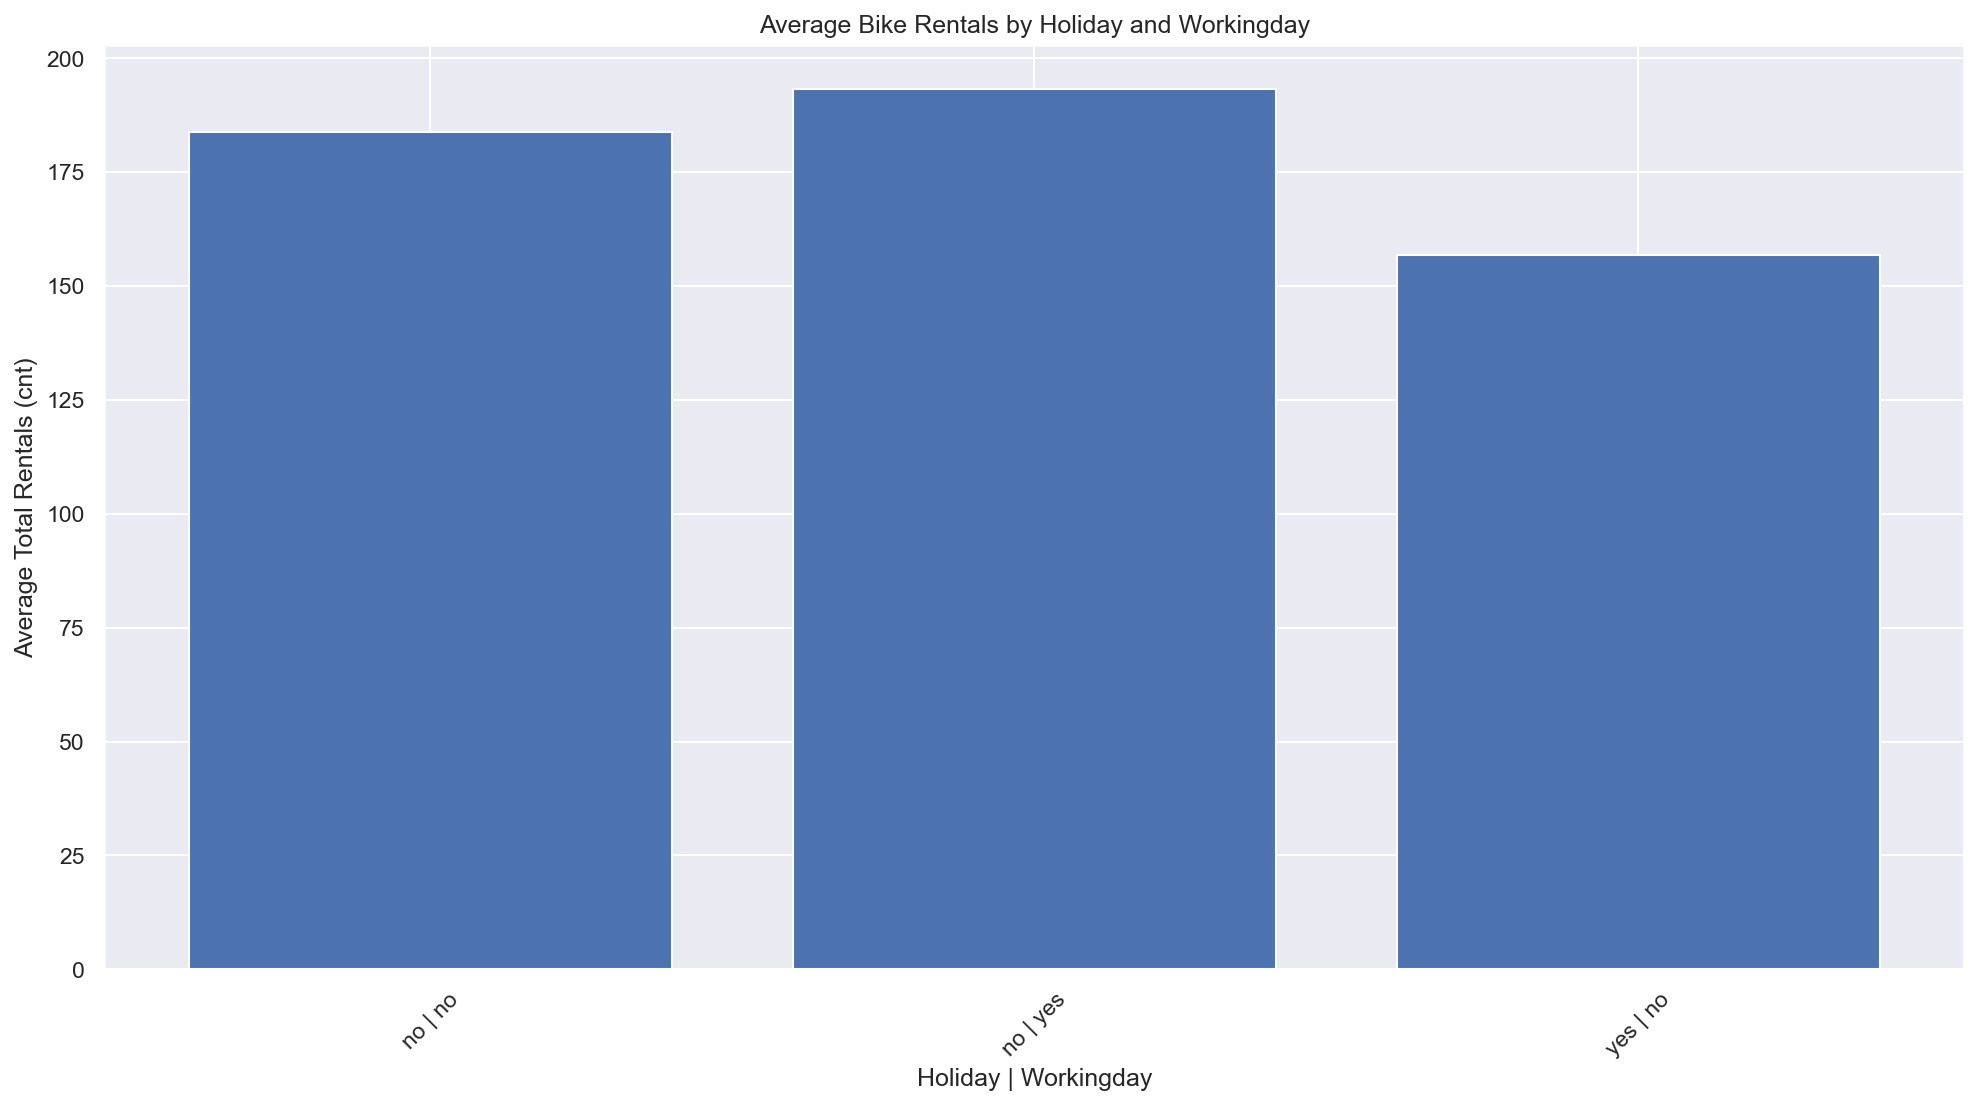

In [37]:
#summary = bike.groupby(['holiday', 'workingday'])['cnt'].mean().reset_index()


#summary['label'] = summary['holiday'] + " | " + summary['workingday']

#plt.figure()
#plt.bar(summary['label'], summary['cnt'])

#plt.xticks(rotation=45)
#plt.xlabel("Holiday | Workingday")
#plt.ylabel("Average Total Rentals (cnt)")
#plt.title("Average Bike Rentals by Holiday and Workingday")
#plt.savefig("final_viz.png", dpi=300, bbox_inches="tight")

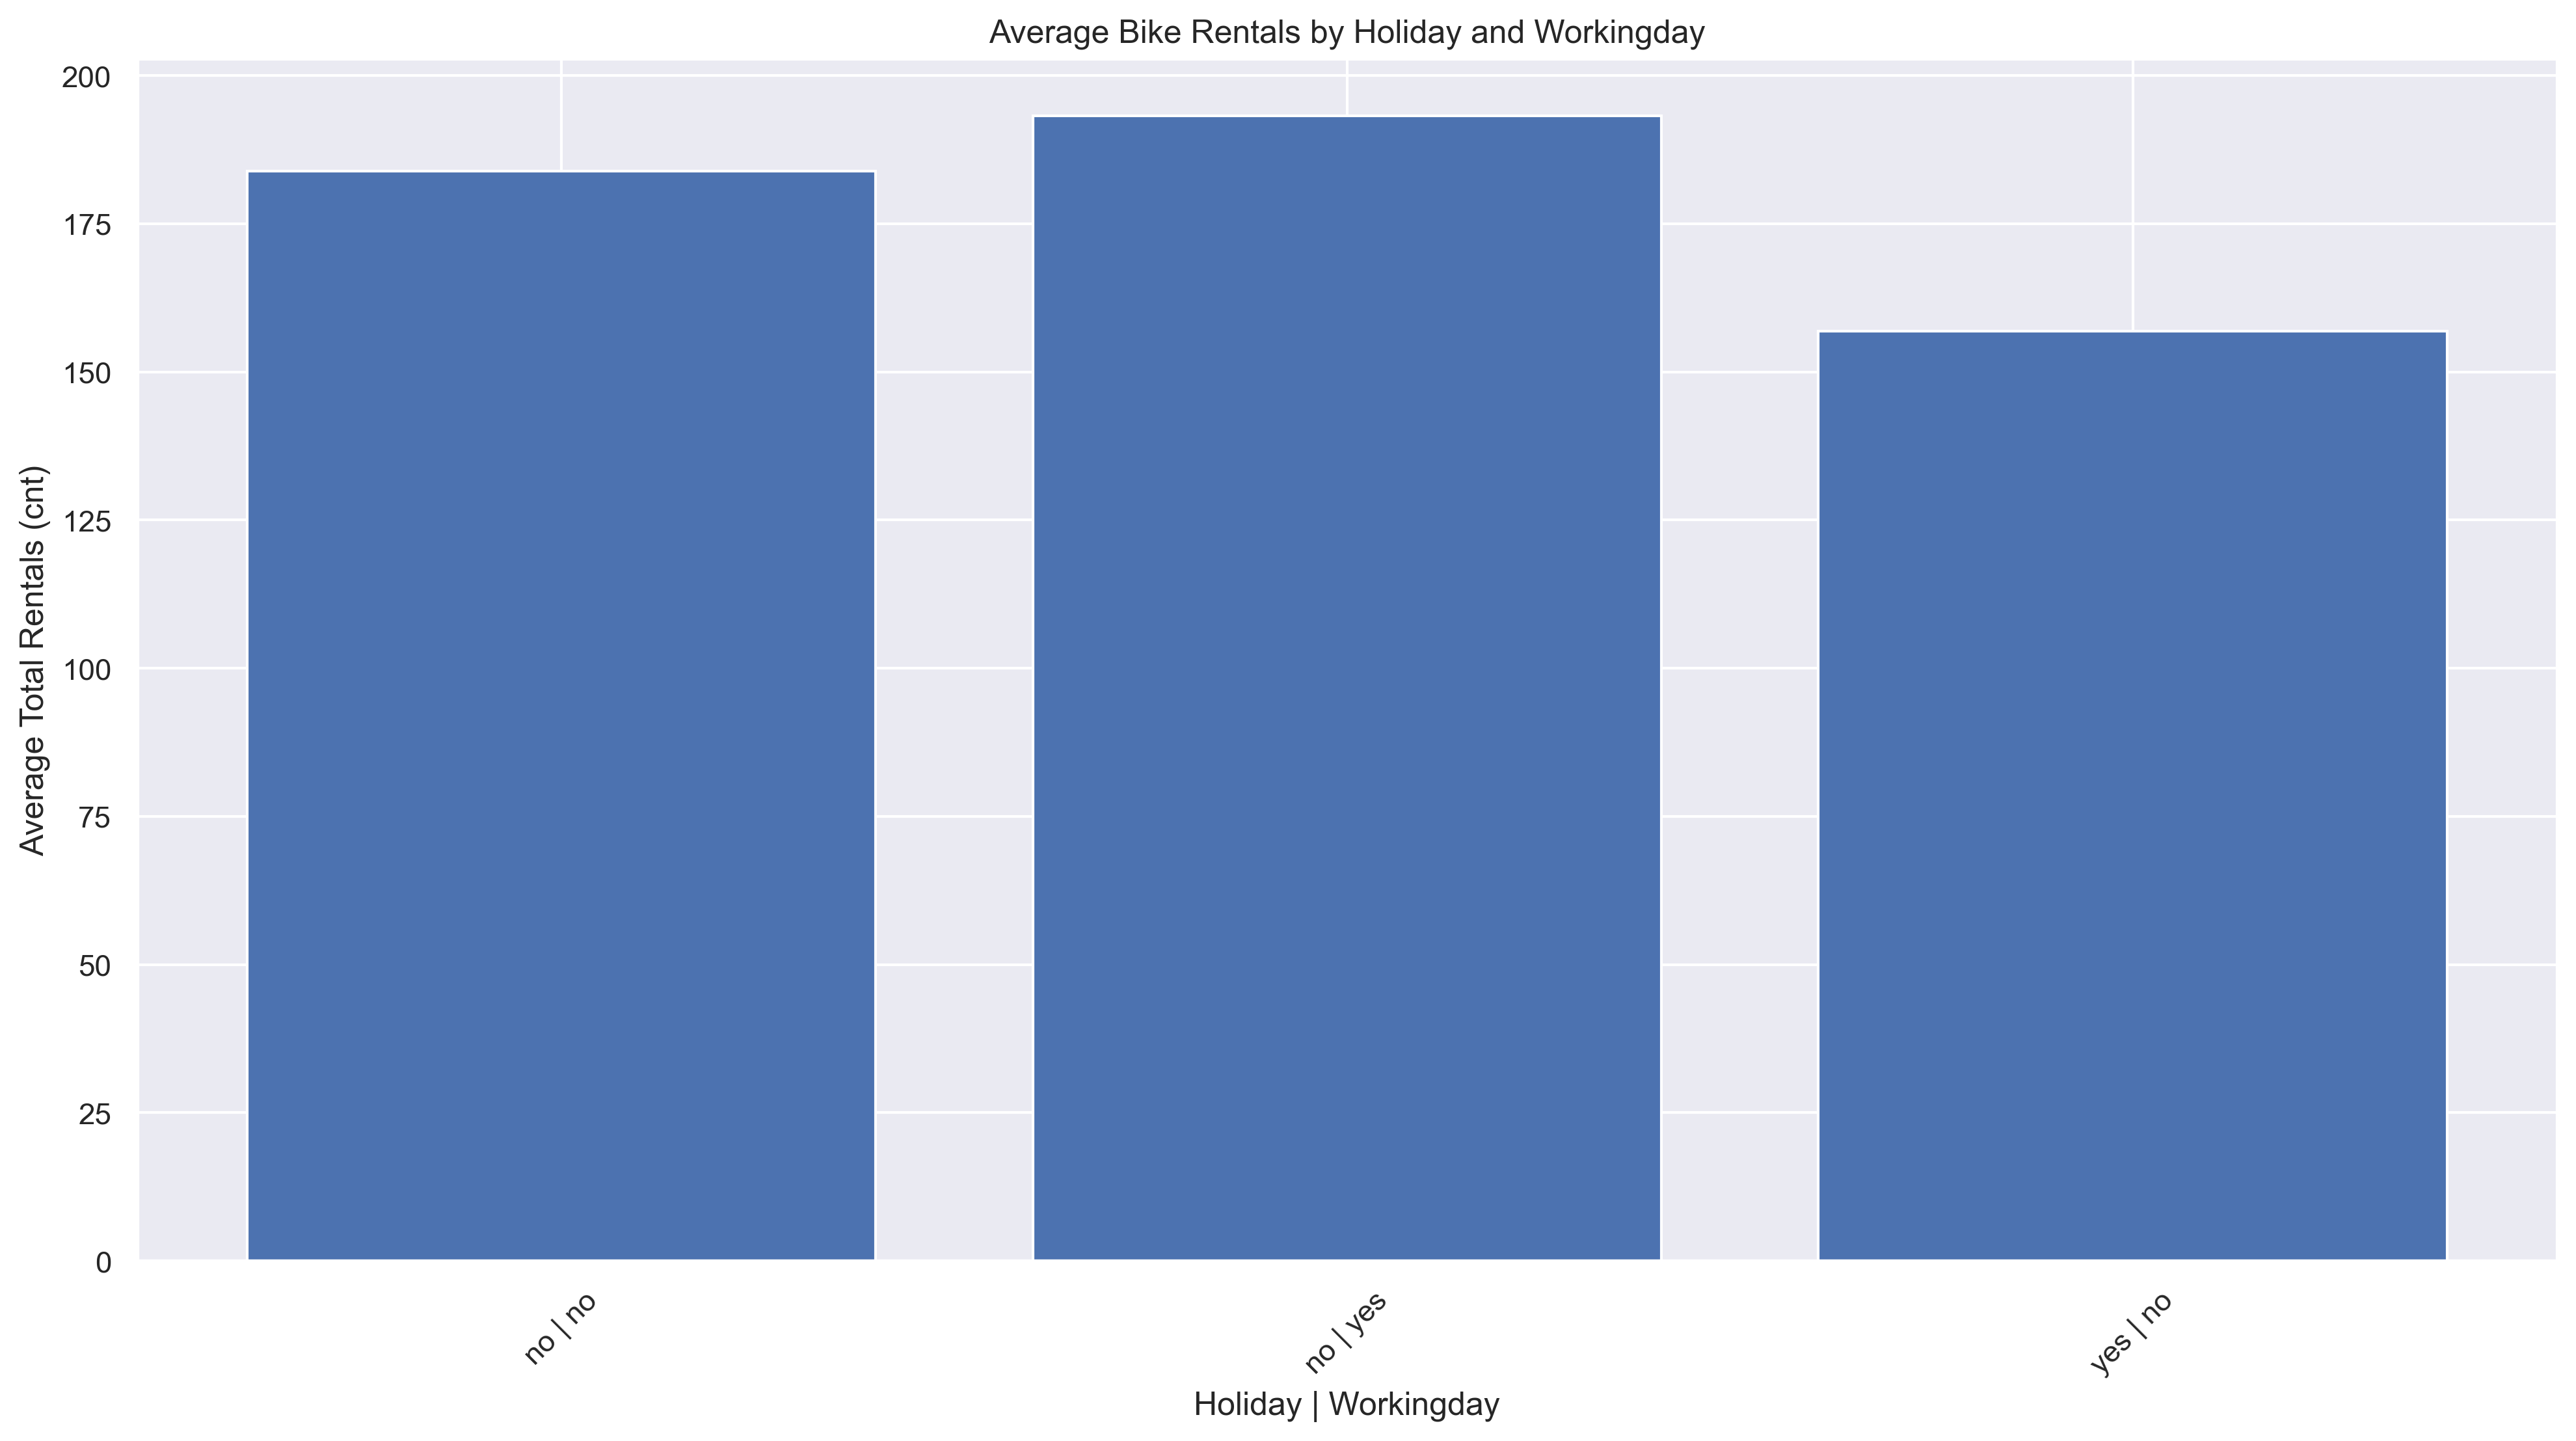

In [38]:
# DO NOT EDIT THIS CELL
# Run this cell and make sure the image that appears is the visualization you want

#from IPython.display import Image

#Image("final_viz.png")

In [42]:
# Set commented_out = True once you have commented out all your code from the scratch cells

commented_out = True

_The visualization shows that average bike rentals are highest on working days, followed by non-working days, and lowest on holidays. This suggests that commuting demand drives the majority of total ridership. Based on this pattern, I propose offering discounted monthly membership plans during working days to encourage consistent commuter usage and lock in stable demand. Since working-day riders likely travel regularly for work, a monthly pass would align with their predictable riding behavior.

For holidays, where average rentals are comparatively lower, I suggest introducing single-ride coupons to attract occasional or leisure riders who may not commit to long-term memberships. However, a potential counterargument is that monthly pass users may already ride frequently regardless of discounts, meaning the profit margin per rider could shrink without significantly increasing total usage. Additionally, holiday demand may already be relatively strong due to leisure travel, and single-ride promotions—if priced too high—might not effectively attract additional users. Despite these risks, a differentiated strategy targeting commuter stability and holiday flexibility could maximize overall system utilization._

In [43]:
grader.check("q7")

q7 results: All test cases passed!

<!-- END QUESTION -->

<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Congratulations! You have finished Homework 4!
# Robin says "Brilliant!" (with a British Accent)
<img src = "images/robin.jpg" width = "500">

### Course Content Feedback

If you have any feedback about this assignment or about any of our other assignments, lectures, or discussions, please fill out the [Course Content Feedback Form](https://docs.google.com/forms/d/e/1FAIpQLScGQhiTz1qn5gsyYUu1Be5Yz0Z_kplIRR_os8UGMOAO8cc-yQ/viewform?usp=dialog). Your input is valuable in helping us improve the quality and relevance of our content to better meet your needs and expectations!

### Submission Instructions

Below, you will see a cell. Running this cell will automatically generate a zip file with your autograded answers. Once you submit this file to the HW 4 Coding assignment on Pensieve, Pensieve will automatically submit a PDF file with your written answers to the HW 4 Written assignment. If you run into any issues when running this cell, feel free to check this [section](https://ds100.org/debugging-guide/autograder_gradescope/autograder_gradescope.html#why-does-grader.exportrun_teststrue-fail-if-all-previous-tests-passed) in the Data 100 Debugging Guide.

**Important**: Please check that your **plots/graphs and written responses** were generated and submitted correctly to the HW 4 Written Assignment.

**You are responsible for ensuring your submission follows our requirements and that the PDF for HW 4 written answers was generated/submitted correctly. We will not be granting regrade requests nor extensions to submissions that don't follow instructions.** If you encounter any difficulties with submission, please don't hesitate to reach out to staff prior to the deadline. 

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

In [44]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)